In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [12]:
df = pd.read_csv("cleaned_data.csv")


In [13]:
df


,Patient name,Age,Gender,Condition,Medication,Visit date,Blood pressure,Cholesterol,Email,Phone number,Systolic,Diastolic
0,David Lee,25.0,Other,Heart Disease,METFORMIN,2020-01-15,140/90,200.0,name@hospital.org,555-555-5555,140.0,90.0
1,Emily Davis,40.0,Male,Diabetes,No_Medication,2018-04-05,120/80,200.0,Unknown,Unknown,120.0,80.0
2,Laura Martinez,35.0,Other,Asthma,METFORMIN,2019-12-01,110/70,160.0,contact@domain.com,Unknown,110.0,70.0
3,Michael Wilson,40.0,Male,Diabetes,ALBUTEROL,2020-01-15,110/70,180.0,name@hospital.org,555-555-5555,110.0,70.0
4,David Lee,40.0,Female,Asthma,No_Medication,2020-02-20,110/70,180.0,Unknown,,110.0,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,Mary Clark,70.0,Other,Asthma,ALBUTEROL,2019-03-25,110/70,180.0,name@hospital.org,Unknown,110.0,70.0
996,Mary Clark,40.0,Other,NaN,LISINOPRIL,2020-01-15,130/85,160.0,Unknown,123-456-7890,130.0,85.0
997,Laura Martinez,40.0,Other,NaN,ALBUTEROL,2020-02-20,110/70,180.0,name@hospital.org,Unknown,110.0,70.0
998,Jane Smith,25.0,Male,NaN,ALBUTEROL,2018-04-05,110/70,200.0,Unknown,,110.0,70.0


In [14]:
X = df[['Age', 'Cholesterol', 'Systolic', 'Diastolic']].values


In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [59]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.347
K=3, Silhouette Score=0.341
K=4, Silhouette Score=0.363
K=5, Silhouette Score=0.351
K=6, Silhouette Score=0.367
K=7, Silhouette Score=0.381
K=8, Silhouette Score=0.398
K=9, Silhouette Score=0.410


In [60]:
km = KMeans(n_clusters=9, n_init=10, random_state=0)
km_lbl = km.fit_predict(X_scaled)

In [61]:
km_center = scaler.inverse_transform(km.cluster_centers_)


In [62]:
km_sil = silhouette_score(X_scaled, km_lbl)


In [70]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
centers_pca = pca.transform(km.cluster_centers_)


In [71]:
COLORS = ["red", "green", "blue"]


In [72]:
plt.figure(figsize=(6, 4))


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

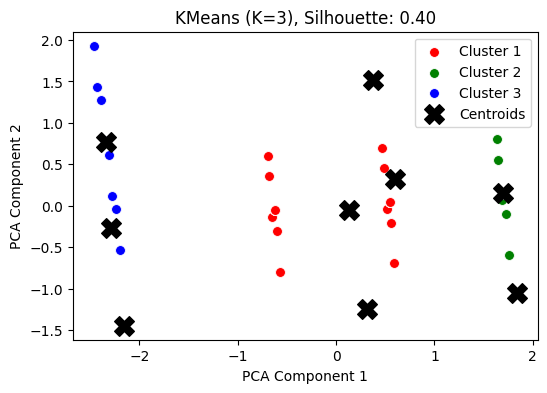

In [73]:
plt.figure(figsize=(6, 4))

for i in range(3):
    m = km_lbl == i
    plt.scatter(X_pca[m, 0], X_pca[m, 1],
                c=COLORS[i], s=50, edgecolors="w",
                lw=0.6, label=f"Cluster {i+1}")

plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c="black", marker="X", s=200, label="Centroids")

plt.title(f"KMeans (K=3), Silhouette: {km_sil:.2f}")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()

plt.show()